In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/egypt_real_estate_listings.csv")
df.head()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31-Aug-25,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2-Sep-25,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19-Aug-25,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26-Aug-25,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2-Sep-25,Cash,"2,262,500 EGP"


| Column Name        | Description                                                                             |
| ------------------ | --------------------------------------------------------------------------------------- |
| **url**            | Direct link to the property listing page on the real estate website.                    |
| **price**          | Total property price in Egyptian Pounds (EGP). Stored as text with commas.              |
| **description**    | Marketing description of the property including features, project name, and highlights. |
| **location**       | Full location hierarchy (compound → area → city → governorate).                         |
| **type**           | Property type (e.g., Apartment, Villa, Chalet).                                         |
| **size**           | Property area shown in both square feet (sqft) and square meters (sqm).                 |
| **bedrooms**       | Number of bedrooms (sometimes includes extras like “1+ Maid”).                          |
| **bathrooms**      | Number of bathrooms.                                                                    |
| **available_from** | Expected delivery or availability date of the property.                                 |
| **payment_method** | Payment type (e.g., Cash or Installments).                                              |
| **down_payment**   | Required initial payment amount in EGP (stored as text).                                |



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [ ]:
df.describe()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,9,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1-Sep-25,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6610,3254,15521,203


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
down_payment,14479
available_from,663
payment_method,541
price,539
bedrooms,144
bathrooms,140
location,91
description,78
size,77
type,77


In [ ]:
df.shape

(19924, 11)

In [ ]:
df.drop(["url","description"],axis=1 , inplace=True)

In [ ]:
df["down_payment"].nunique()

2030

In [ ]:
df.dropna(subset=["price","location","size","bedrooms","bathrooms","type","available_from","payment_method"],inplace=True)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
down_payment,13474
price,0
location,0
size,0
type,0
bedrooms,0
bathrooms,0
available_from,0
payment_method,0


In [ ]:
df.head()

,price,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,"8,000,000","Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31-Aug-25,Cash,"1,200,000 EGP"
1,"25,000,000","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2-Sep-25,Cash,"2,100,000 EGP"
2,"15,135,000","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19-Aug-25,Cash,"1,513,000 EGP"
3,"12,652,000","Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26-Aug-25,Installments,"1,260,000 EGP"
4,"45,250,000","Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2-Sep-25,Cash,"2,262,500 EGP"


In [ ]:
df["price"].str.replace(",","").astype(int)

,price
0,8000000
1,25000000
2,15135000
3,12652000
4,45250000
...,...
19919,10500000
19920,24000000
19921,3000000
19922,9500000


In [ ]:
int(df['price'][0].replace(',',''))

8000000

In [ ]:
def repl(st):
   return int(st.replace(',',''))

In [ ]:
df['price'].apply(repl)

,price
0,8000000
1,25000000
2,15135000
3,12652000
4,45250000
...,...
19919,10500000
19920,24000000
19921,3000000
19922,9500000


In [ ]:
df['price'] = df['price'].str.replace(",","").astype('int')

In [ ]:
df.head()

,price,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,8000000,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31-Aug-25,Cash,"1,200,000 EGP"
1,25000000,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2-Sep-25,Cash,"2,100,000 EGP"
2,15135000,"Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19-Aug-25,Cash,"1,513,000 EGP"
3,12652000,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26-Aug-25,Installments,"1,260,000 EGP"
4,45250000,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2-Sep-25,Cash,"2,262,500 EGP"


In [ ]:
df["size"][0].split(" ")[3]

'68'

In [ ]:
df["size"][0].split(" ")[0]

'732'

In [ ]:
def size_split(ST):
    return int(ST.split(" ")[3].replace(',',''))

In [ ]:
df['size']

,size
0,732 sqft / 68 sqm
1,"2,368 sqft / 220 sqm"
2,"1,270 sqft / 118 sqm"
3,"1,787 sqft / 166 sqm"
4,"4,306 sqft / 400 sqm"
...,...
19919,"1,259 sqft / 117 sqm"
19920,"2,756 sqft / 256 sqm"
19921,"1,195 sqft / 111 sqm"
19922,"2,573 sqft / 239 sqm"


In [ ]:
df['size'] = df['size'].apply(size_split)

In [ ]:
df.head()

,price,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,8000000,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,68,1+ Maid,1,31-Aug-25,Cash,"1,200,000 EGP"
1,25000000,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,220,4,4,2-Sep-25,Cash,"2,100,000 EGP"
2,15135000,"Azha North, Ras Al Hekma, North Coast",Chalet,118,2,2,19-Aug-25,Cash,"1,513,000 EGP"
3,12652000,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,166,3,2,26-Aug-25,Installments,"1,260,000 EGP"
4,45250000,"Granville, New Capital City, Cairo",Villa,400,7,7,2-Sep-25,Cash,"2,262,500 EGP"


In [ ]:
df['bedrooms'].unique()

array(['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
       '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid',
       'studio+ Maid', '7++ Maid', '7+', '6'], dtype=object)

In [ ]:
df['bedrooms'].value_counts()

,count
bedrooms,
3,4785
3+ Maid,3549
2,2762
4+ Maid,1965
2+ Maid,1676
4,1059
1,726
5+ Maid,680
1+ Maid,433


In [ ]:
import pandas as pd
import re

def parse_bedrooms(value):
    value = str(value).lower().strip()

    bedrooms = 0
    studio = 0
    maid = 0

    # Studio
    if "studio" in value:
        studio = 1
        bedrooms = 0
        if "maid" in value:
            maid = 1
        return bedrooms, studio, maid

    # Maid bedroom
    if "maid" in value:
        maid = 1

    # 7+ or 7++
    if re.search(r'7\+{1,2}', value):
        bedrooms = 8
    else:
        match = re.search(r'\d+', value)
        if match:
            bedrooms = int(match.group())

    return bedrooms, studio, maid


df[['bedrooms_clean', 'studio', 'maid_bedroom']] = df['bedrooms'].apply(
    lambda x: pd.Series(parse_bedrooms(x))
)


In [ ]:
['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
       '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid',
       'studio+ Maid', '7++ Maid', '7+', '6']

['1+ Maid',
 '4',
 '2',
 '3',
 '7',
 '5+ Maid',
 '3+ Maid',
 '2+ Maid',
 '1',
 '4+ Maid',
 '7+ Maid',
 'studio',
 '5',
 '6+ Maid',
 'studio+ Maid',
 '7++ Maid',
 '7+',
 '6']

In [ ]:
df[df['bedrooms'] =="7++ Maid"]

,price,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom
726,199000000,"The Waterway, Qesm Ad Dabaah, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
1142,110000000,"Silver Sands, Qesm Marsa Matrouh, North Coast",Whole Building,730,7++ Maid,7+,2-Sep-25,Cash,"5,000,000 EGP",8,0,1
1253,199000000,"Caesar, Qesm Marsa Matrouh, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
2302,199000000,"Soul North Coast, Qesm Ad Dabaah, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
2632,199000000,"Beit Al Bahr, Sidi Heneish, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
2991,199000000,"Ramla Lakeside, Qesm Ad Dabaah, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
4161,199000000,"Marassi, Sidi Abdel Rahman, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
4327,199000000,"South Med, Qesm Ad Dabaah, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
4524,199000000,"Zoya, Sidi Abdel Rahman, North Coast",Palace,950,7++ Maid,7+,1-Sep-25,Installments,"19,900,000 EGP",8,0,1
4612,70620000,"Soul North Coast, Qesm Ad Dabaah, North Coast",Villa,429,7++ Maid,4,2-Sep-25,Cash,"29,430,000 EGP",8,0,1


In [ ]:
df.drop("bedrooms",axis=1,inplace=True)

In [ ]:
df.head()

,price,location,type,size,bathrooms,available_from,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom
0,8000000,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,68,1,31-Aug-25,Cash,"1,200,000 EGP",1,0,1
1,25000000,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,220,4,2-Sep-25,Cash,"2,100,000 EGP",4,0,0
2,15135000,"Azha North, Ras Al Hekma, North Coast",Chalet,118,2,19-Aug-25,Cash,"1,513,000 EGP",2,0,0
3,12652000,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,166,2,26-Aug-25,Installments,"1,260,000 EGP",3,0,0
4,45250000,"Granville, New Capital City, Cairo",Villa,400,7,2-Sep-25,Cash,"2,262,500 EGP",7,0,0


In [ ]:
df = df[df['bathrooms']!='none']

In [ ]:
df["bathrooms"] = df["bathrooms"].str.replace("7+","8").astype(int)

In [ ]:
df.head()

,price,location,type,size,bathrooms,available_from,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom
0,8000000,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,68,1,31-Aug-25,Cash,"1,200,000 EGP",1,0,1
1,25000000,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,220,4,2-Sep-25,Cash,"2,100,000 EGP",4,0,0
2,15135000,"Azha North, Ras Al Hekma, North Coast",Chalet,118,2,19-Aug-25,Cash,"1,513,000 EGP",2,0,0
3,12652000,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,166,2,26-Aug-25,Installments,"1,260,000 EGP",3,0,0
4,45250000,"Granville, New Capital City, Cairo",Villa,400,7,2-Sep-25,Cash,"2,262,500 EGP",7,0,0


In [ ]:
df['available_from'] = pd.to_datetime(df['available_from'])

/tmp/ipykernel_234/3783821494.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['available_from'] = pd.to_datetime(df['available_from'])


In [ ]:
df['year'] = df['available_from'].dt.year
df['month'] = df['available_from'].dt.month
df['day'] = df['available_from'].dt.day

In [ ]:
df.drop(['available_from'],axis=1 ,inplace=True)

In [ ]:
df.head()

,price,location,type,size,bathrooms,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom,year,month,day
0,8000000,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,68,1,Cash,"1,200,000 EGP",1,0,1,2025,8,31
1,25000000,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,220,4,Cash,"2,100,000 EGP",4,0,0,2025,9,2
2,15135000,"Azha North, Ras Al Hekma, North Coast",Chalet,118,2,Cash,"1,513,000 EGP",2,0,0,2025,8,19
3,12652000,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,166,2,Installments,"1,260,000 EGP",3,0,0,2025,8,26
4,45250000,"Granville, New Capital City, Cairo",Villa,400,7,Cash,"2,262,500 EGP",7,0,0,2025,9,2


In [ ]:
df['down_payment'] = df['down_payment'].fillna("0 EGP").str.replace(",","").str.split(" ").str[0].astype(int)

In [ ]:
df.head()

,price,location,type,size,bathrooms,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom,year,month,day
0,8000000,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,68,1,Cash,1200000,1,0,1,2025,8,31
1,25000000,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,220,4,Cash,2100000,4,0,0,2025,9,2
2,15135000,"Azha North, Ras Al Hekma, North Coast",Chalet,118,2,Cash,1513000,2,0,0,2025,8,19
3,12652000,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,166,2,Installments,1260000,3,0,0,2025,8,26
4,45250000,"Granville, New Capital City, Cairo",Villa,400,7,Cash,2262500,7,0,0,2025,9,2


In [ ]:
df['location'].nunique()

1485

In [ ]:
df['type'].nunique()

14

In [ ]:
df['type'].unique()

array(['Chalet', 'Villa', 'Apartment', 'Penthouse', 'Twin House',
       'Duplex', 'Townhouse', 'Hotel Apartment', 'Cabin', 'iVilla',
       'Palace', 'Whole Building', 'Full Floor', 'Roof'], dtype=object)

In [ ]:
df['payment_method'].unique()

array(['Cash', 'Installments'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df['payment_method'] = lb.fit_transform(df['payment_method'])

In [ ]:
!pip install category-encoders
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.9 MB/s eta 0:00:00


In [ ]:
from category_encoders import TargetEncoder
encoder = TargetEncoder(cols=['location'],
    smoothing=10)
df['location'] = encoder.fit_transform(df['location'], df['price'])
df['location'].head()

,location
0,1.670896e+07
1,1.551593e+07
2,1.770823e+07
3,9.223015e+06
4,1.898152e+07


In [ ]:
df.head()

,price,location,type,size,bathrooms,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom,year,month,day
0,8000000,1.670896e+07,Chalet,68,1,0,1200000,1,0,1,2025,8,31
1,25000000,1.551593e+07,Villa,220,4,0,2100000,4,0,0,2025,9,2
2,15135000,1.770823e+07,Chalet,118,2,0,1513000,2,0,0,2025,8,19
3,12652000,9.223015e+06,Apartment,166,2,1,1260000,3,0,0,2025,8,26
4,45250000,1.898152e+07,Villa,400,7,0,2262500,7,0,0,2025,9,2


In [ ]:
df = pd.get_dummies(df).replace({True:1,False:0})

/tmp/ipykernel_234/2792921389.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.get_dummies(df).replace({True:1,False:0})


In [ ]:
df.head()

,price,location,size,bathrooms,payment_method,down_payment,bedrooms_clean,studio,maid_bedroom,year,...,type_Full Floor,type_Hotel Apartment,type_Palace,type_Penthouse,type_Roof,type_Townhouse,type_Twin House,type_Villa,type_Whole Building,type_iVilla
0,8000000,1.670896e+07,68,1,0,1200000,1,0,1,2025,...,0,0,0,0,0,0,0,0,0,0
1,25000000,1.551593e+07,220,4,0,2100000,4,0,0,2025,...,0,0,0,0,0,0,0,1,0,0
2,15135000,1.770823e+07,118,2,0,1513000,2,0,0,2025,...,0,0,0,0,0,0,0,0,0,0
3,12652000,9.223015e+06,166,2,1,1260000,3,0,0,2025,...,0,0,0,0,0,0,0,0,0,0
4,45250000,1.898152e+07,400,7,0,2262500,7,0,0,2025,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18768 entries, 0 to 19923
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   price                 18768 non-null  int64  
 1   location              18768 non-null  float64
 2   size                  18768 non-null  int64  
 3   bathrooms             18768 non-null  int64  
 4   payment_method        18768 non-null  int64  
 5   down_payment          18768 non-null  int64  
 6   bedrooms_clean        18768 non-null  int64  
 7   studio                18768 non-null  int64  
 8   maid_bedroom          18768 non-null  int64  
 9   year                  18768 non-null  int32  
 10  month                 18768 non-null  int32  
 11  day                   18768 non-null  int32  
 12  type_Apartment        18768 non-null  int64  
 13  type_Cabin            18768 non-null  int64  
 14  type_Chalet           18768 non-null  int64  
 15  type_Duplex           18

<Axes: >

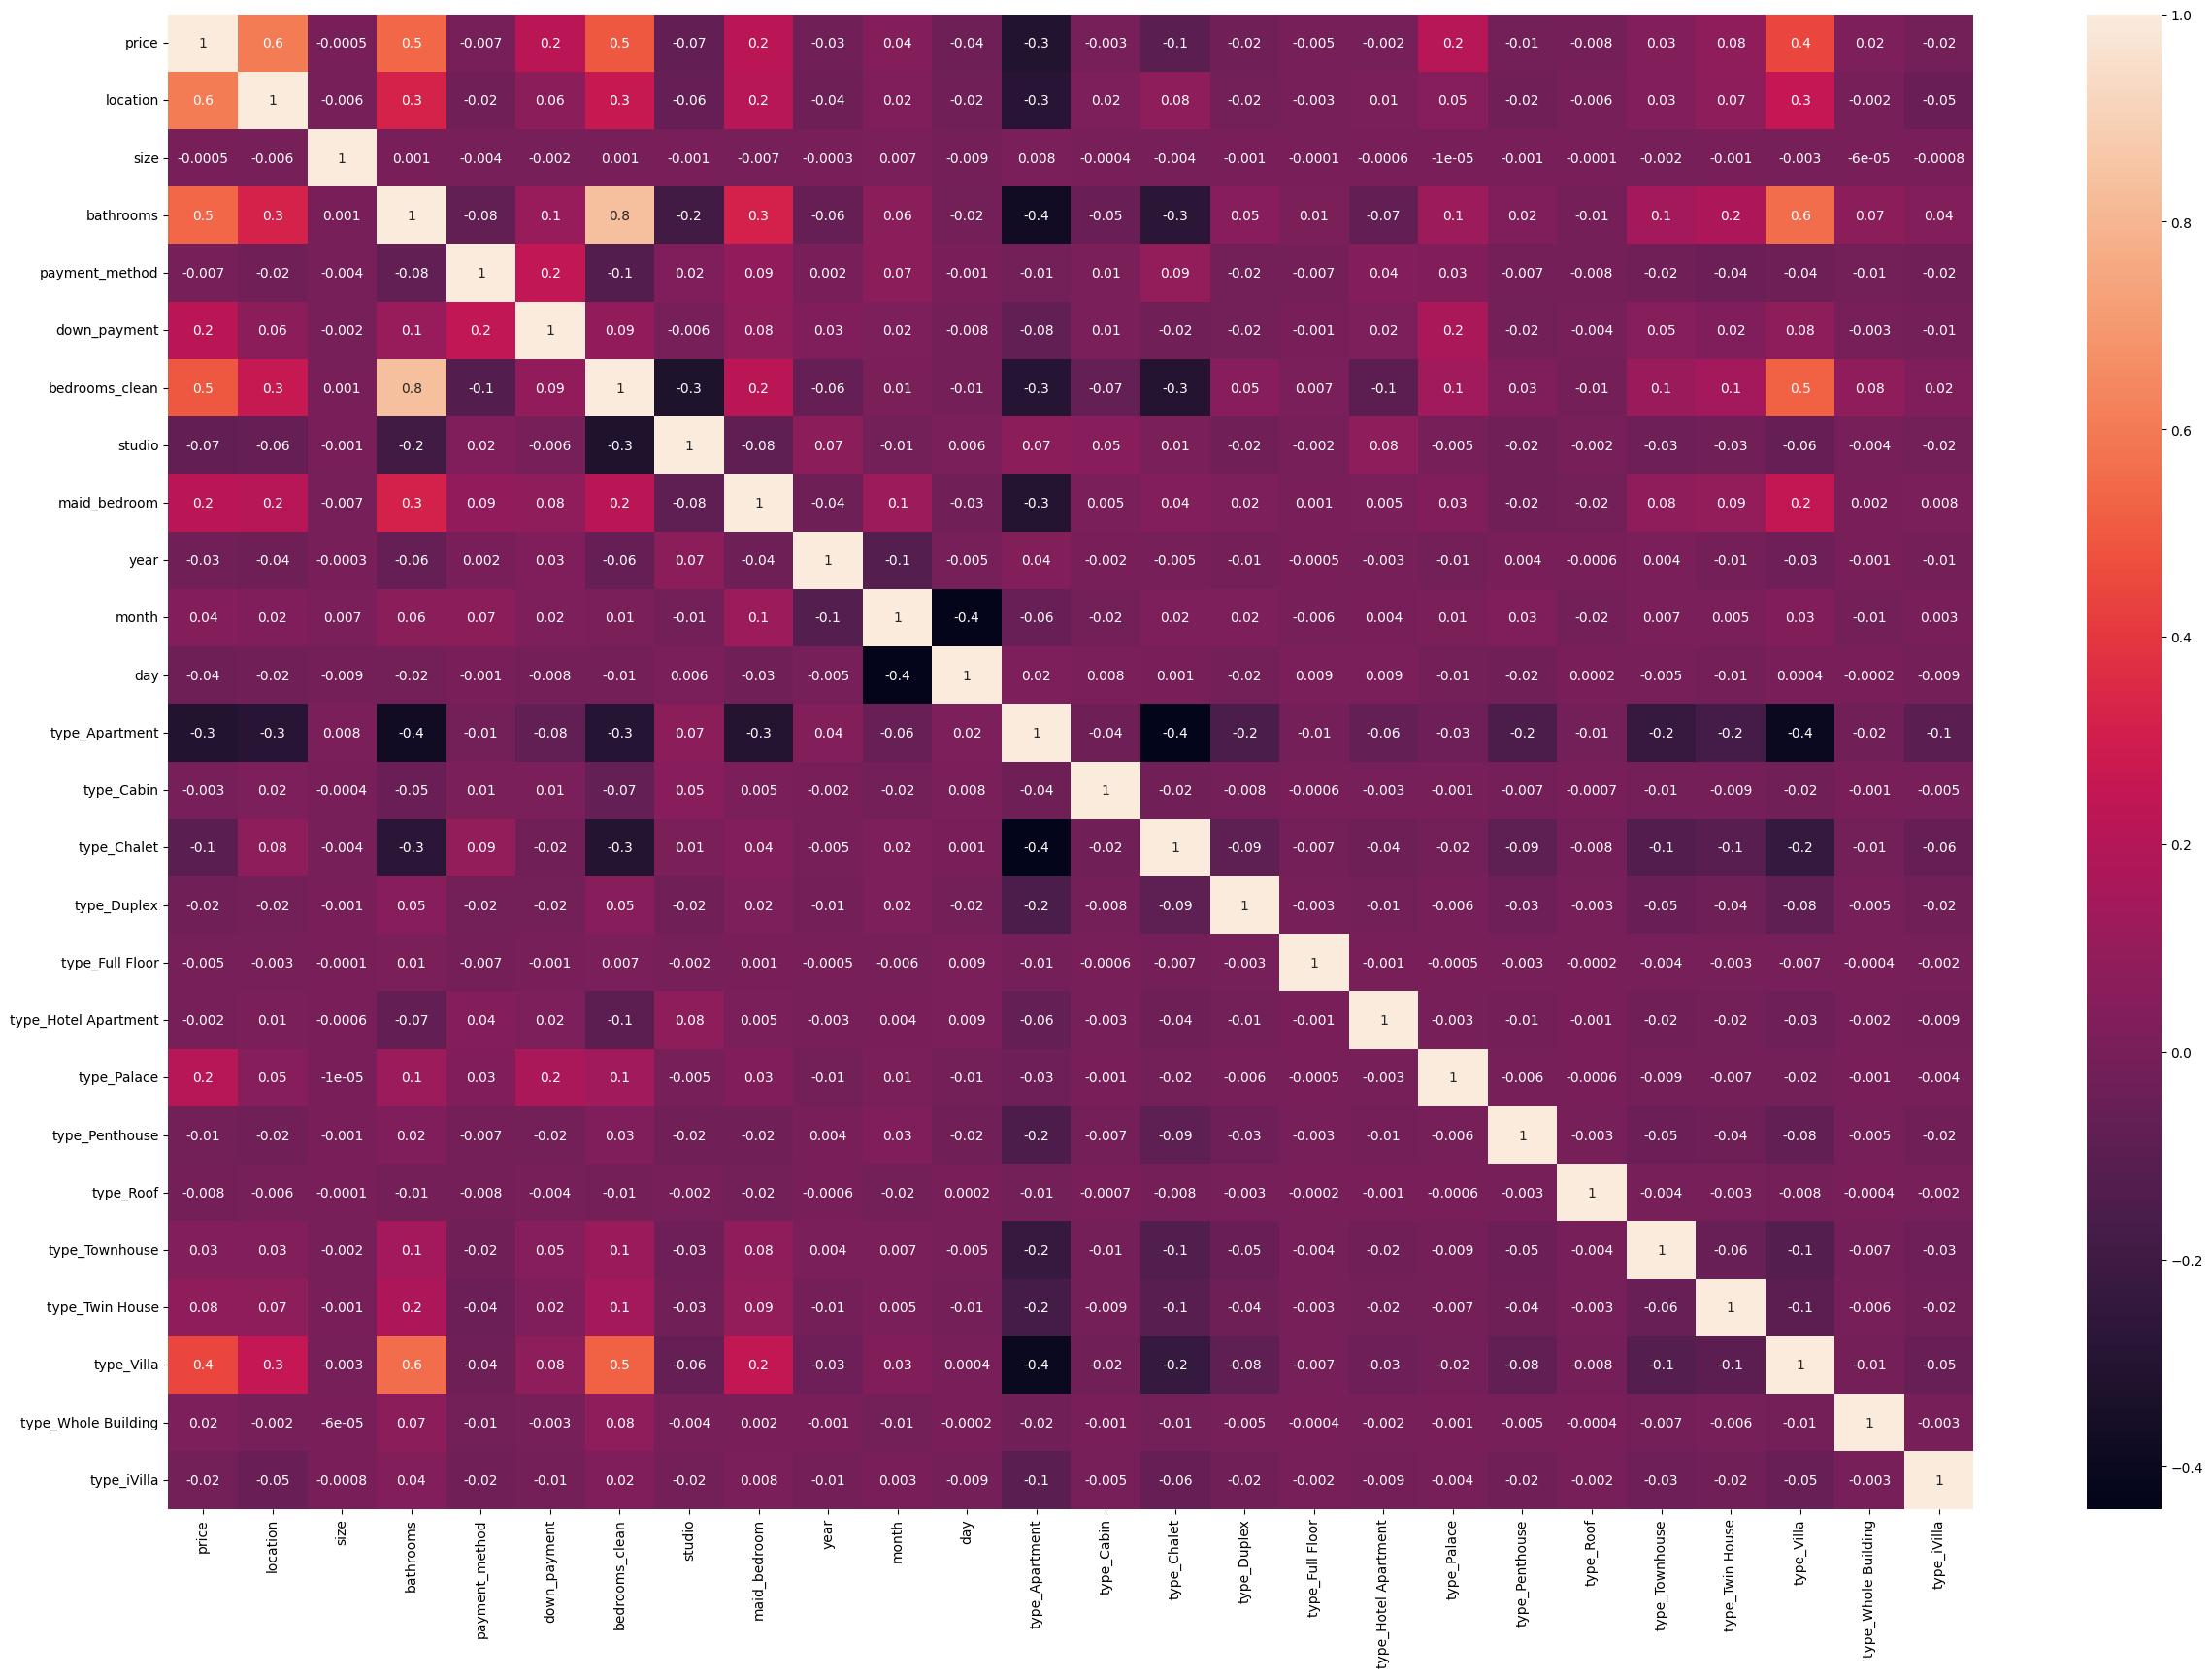

In [ ]:
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(),annot=True,fmt='0.1g')

In [ ]:
corr_cols = (
    df.corr(numeric_only=True)['price']
    .drop('price')
    .loc[lambda x: (x > 0.1) | (x < -0.1)]
    .index
)
corr_cols

Index(['location', 'bathrooms', 'down_payment', 'bedrooms_clean',
       'maid_bedroom', 'type_Apartment', 'type_Chalet', 'type_Palace',
       'type_Villa'],
      dtype='object')

In [ ]:
df = df[['price','location', 'bathrooms', 'down_payment', 'bedrooms_clean',
       'maid_bedroom', 'type_Apartment', 'type_Chalet', 'type_Palace',
       'type_Villa']]

In [ ]:
X =df.drop(["price"],axis=1)
y = df["price"]

In [ ]:
X.describe()

,location,bathrooms,down_payment,bedrooms_clean,maid_bedroom,type_Apartment,type_Chalet,type_Palace,type_Villa
count,1.876800e+04,18768.000000,1.876800e+04,18768.000000,18768.000000,18768.000000,18768.000000,18768.000000,18768.000000
mean,1.705118e+07,2.937500,5.513288e+05,2.959719,0.465367,0.429135,0.205083,0.001225,0.174393
std,1.114197e+07,1.303714,1.972748e+06,1.193121,0.498812,0.494966,0.403773,0.034986,0.379457
min,2.843477e+06,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.169183e+07,2.000000,0.000000e+00,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.449976e+07,3.000000,0.000000e+00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.875711e+07,4.000000,1.644175e+05,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,1.456302e+08,8.000000,6.800000e+07,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000


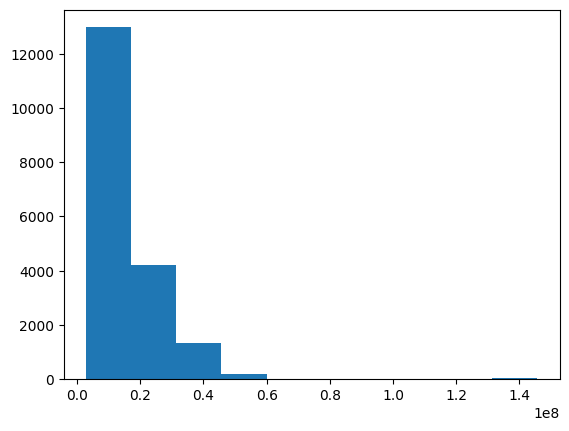

In [ ]:
plt.hist(df['location'])
plt.show()

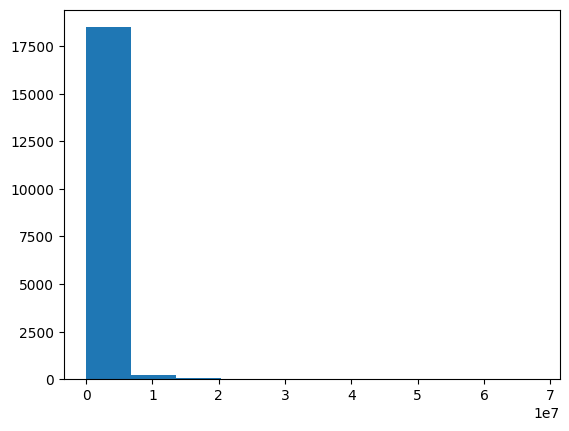

In [ ]:
plt.hist(df['down_payment'])
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=44)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((15014, 9), (3754, 9), (15014,), (3754,))

In [ ]:
X_train.describe()

,location,bathrooms,down_payment,bedrooms_clean,maid_bedroom,type_Apartment,type_Chalet,type_Palace,type_Villa
count,1.501400e+04,15014.000000,1.501400e+04,15014.000000,15014.000000,15014.000000,15014.000000,15014.000000,15014.000000
mean,1.706550e+07,2.929599,5.646959e+05,2.951179,0.465699,0.428866,0.207207,0.001399,0.171773
std,1.115757e+07,1.297400,2.068232e+06,1.183188,0.498839,0.494931,0.405318,0.037374,0.377196
min,2.843477e+06,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.169183e+07,2.000000,0.000000e+00,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.450101e+07,3.000000,0.000000e+00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.875711e+07,4.000000,1.650525e+05,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,1.456302e+08,8.000000,6.800000e+07,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
y_train.describe()

,price
count,1.501400e+04
mean,1.626123e+07
std,2.199161e+07
min,1.869000e+05
25%,6.000000e+06
50%,1.043150e+07
75%,1.850000e+07
max,6.500000e+08


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
model.score(X_train,y_train)

0.5869425365596712

In [ ]:
model.score(X_test,y_test)

0.4764991170041757

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mean_absolute_error(y_test,y_pred)

7391897.251363744

In [ ]:
mean_squared_error(y_test,y_pred)

379573042774139.56

In [ ]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(19482634.38999304)

In [ ]:
r2_score(y_test,y_pred)

0.4764991170041757

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression , Lasso ,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # Needed for HistGB
from sklearn.ensemble import (RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,
                              AdaBoostRegressor ,GradientBoostingRegressor,HistGradientBoostingRegressor
                              , VotingRegressor,StackingRegressor)
#import xgboost as xgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
#import lightgbm as lgb
from lightgbm import LGBMRegressor

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [ ]:
models ={
    "Linear Regression":LinearRegression(),
    #"Lasso":Lasso(),
    #"Ridge":Ridge(),
    #"KNN":KNeighborsRegressor(n_neighbors=5,metric='minkowski',p=1), #  minkowski , euclidean , manhattan
    #"SVM":SVR(kernel='linear', C=100, gamma=1), # kernel='rbf' / kernel='poly', degree=4 / kernel='sigmoid
    "Decision Tree":DecisionTreeRegressor(criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "Random Forest":RandomForestRegressor(n_estimators=50,criterion='squared_error',max_depth=10), #{"squared_error", "friedman_mse", "absolute_error", "poisson"}
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    #"Bagging": BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error',max_depth=10),n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=15, random_state=42),
    #"GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42),
    #"XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    #"CatBoost": CatBoostRegressor(verbose=0, iterations=100, learning_rate=0.1, random_state=42),
    #"LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [ ]:
# Metrics function
def regression_metrics(model, X, y_actual):
    y_pred = model.predict(X)
    MAE = mean_absolute_error(y_actual, y_pred)
    MSE = mean_squared_error(y_actual, y_pred)
    RMSE = np.sqrt(MSE)
    R2 = r2_score(y_actual, y_pred)
    return MAE, MSE, RMSE, R2

  0%|          | 0/6 [00:00<?, ?it/s]

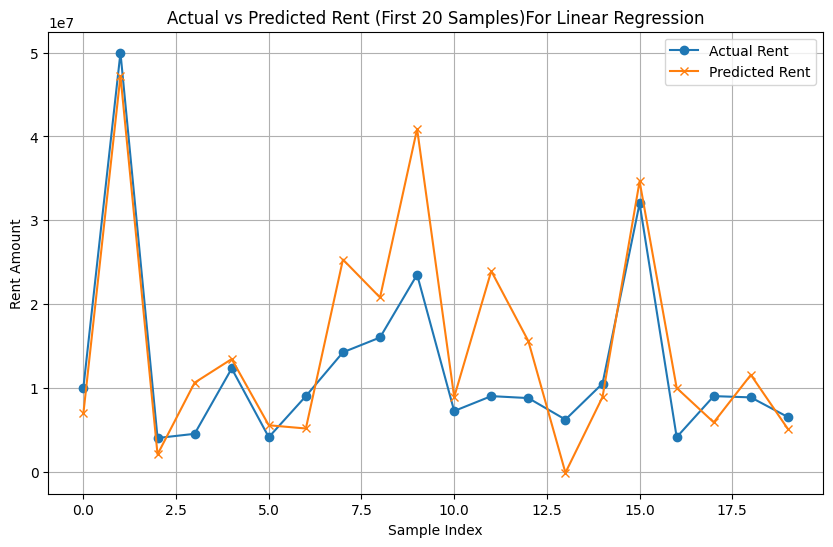

 17%|█▋        | 1/6 [00:00<00:04,  1.12it/s]

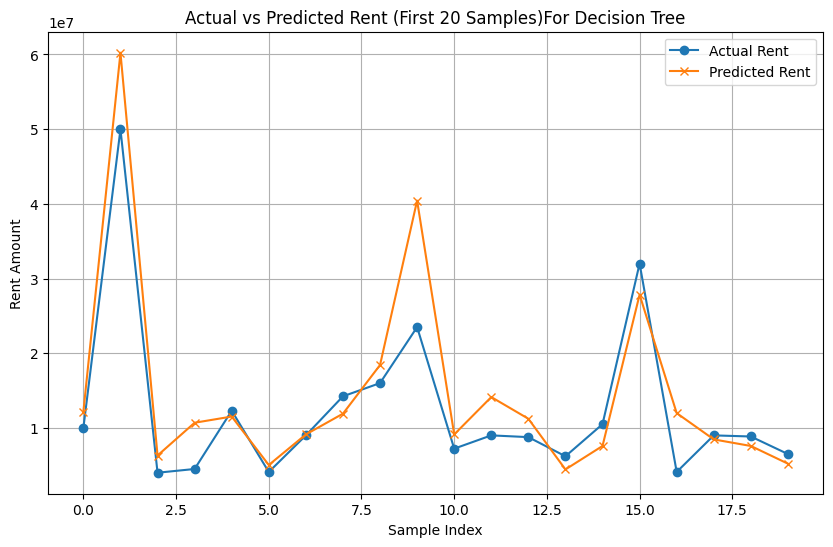

 33%|███▎      | 2/6 [00:01<00:03,  1.27it/s]

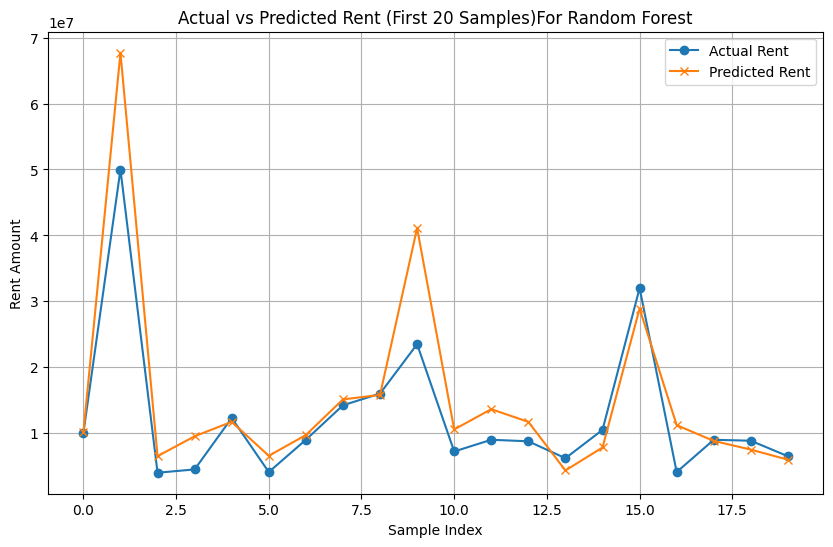

 50%|█████     | 3/6 [00:03<00:04,  1.49s/it]

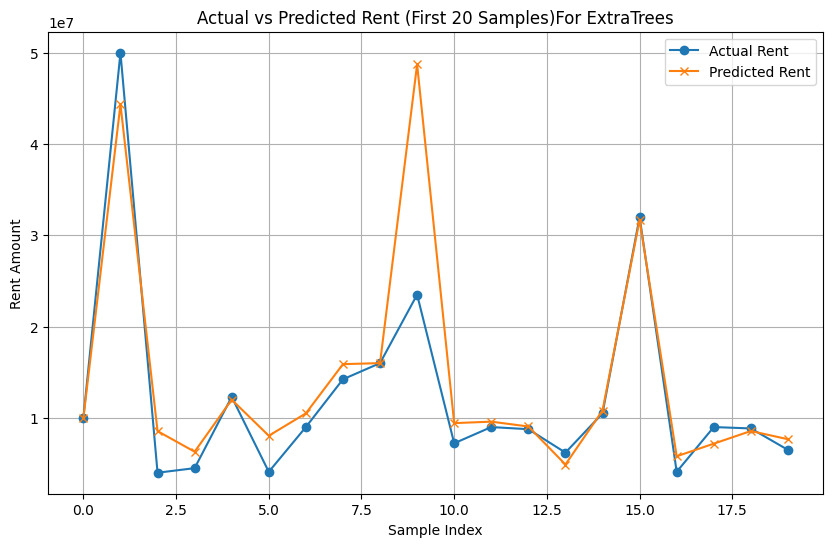

 67%|██████▋   | 4/6 [00:07<00:04,  2.34s/it]

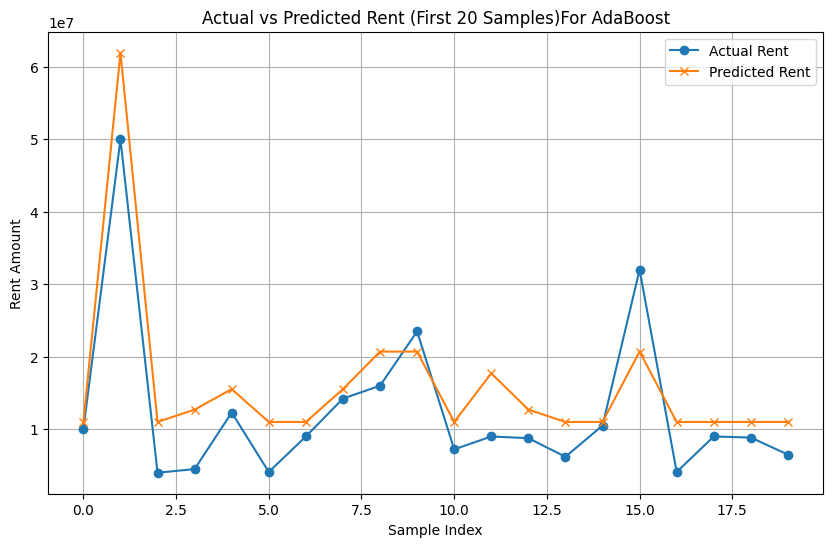

 83%|████████▎ | 5/6 [00:07<00:01,  1.64s/it]

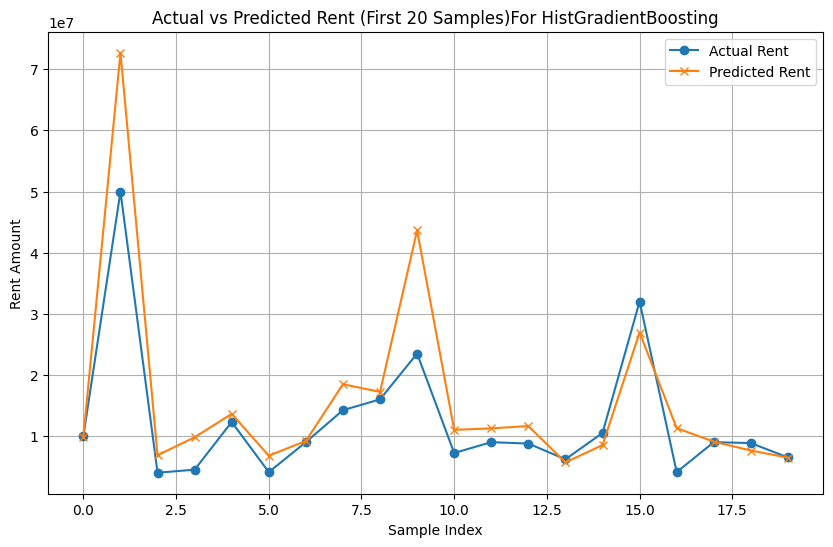

100%|██████████| 6/6 [00:08<00:00,  1.43s/it]


In [ ]:
errors={}
for model_name , model in tqdm(models.items()):
    model.fit(X_train,y_train)
    MAE_Train, MSE_Train, RMSE_Train, R_Train = regression_metrics(model, X_train, y_train)
    MAE_Test, MSE_Test, RMSE_Test, R_Test = regression_metrics(model, X_test, y_test)

    errors[model_name] = {
        "MAE Train":MAE_Train,
        "MAE Test":MAE_Test,
        "MSE Train":MSE_Train,
        "MSE Test":MSE_Test,
        "RMSE Train":RMSE_Train,
        "RMSE Test":RMSE_Test,
        "R2 Train":R_Train,
        "R2 Test":R_Test
    }

    #Plotting Actual vs Predicted for first 20 test samples
    y_test_plot = y_test.values[:20]
    y_pred_plot = model.predict(X_test[:20])

    plt.figure(figsize=(10,6))
    plt.plot(range(20), y_test_plot, label='Actual Rent', marker='o')
    plt.plot(range(20), y_pred_plot, label='Predicted Rent', marker='x')
    plt.xlabel('Sample Index')
    plt.ylabel('Rent Amount')
    plt.title('Actual vs Predicted Rent (First 20 Samples)For '+ model_name)
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
errors_df = pd.DataFrame(errors).T.sort_values(by="R2 Test",ascending=False)

In [ ]:
errors_df

,MAE Train,MAE Test,MSE Train,MSE Test,RMSE Train,RMSE Test,R2 Train,R2 Test
Random Forest,4.451852e+06,5.370808e+06,7.980969e+13,2.444011e+14,8.933627e+06,1.563333e+07,0.834967,0.662926
ExtraTrees,1.673511e+06,5.361817e+06,4.052013e+13,2.563966e+14,6.365542e+06,1.601239e+07,0.916211,0.646382
Decision Tree,4.487750e+06,5.704287e+06,8.009367e+13,2.612568e+14,8.949507e+06,1.616344e+07,0.834380,0.639679
HistGradientBoosting,4.924817e+06,5.616570e+06,1.109717e+14,2.816240e+14,1.053431e+07,1.678166e+07,0.770529,0.611589
AdaBoost,7.776804e+06,8.073700e+06,1.999442e+14,3.184368e+14,1.414016e+07,1.784480e+07,0.586549,0.560817
Linear Regression,7.134377e+06,7.391897e+06,1.997540e+14,3.795730e+14,1.413344e+07,1.948263e+07,0.586943,0.476499


<Axes: >

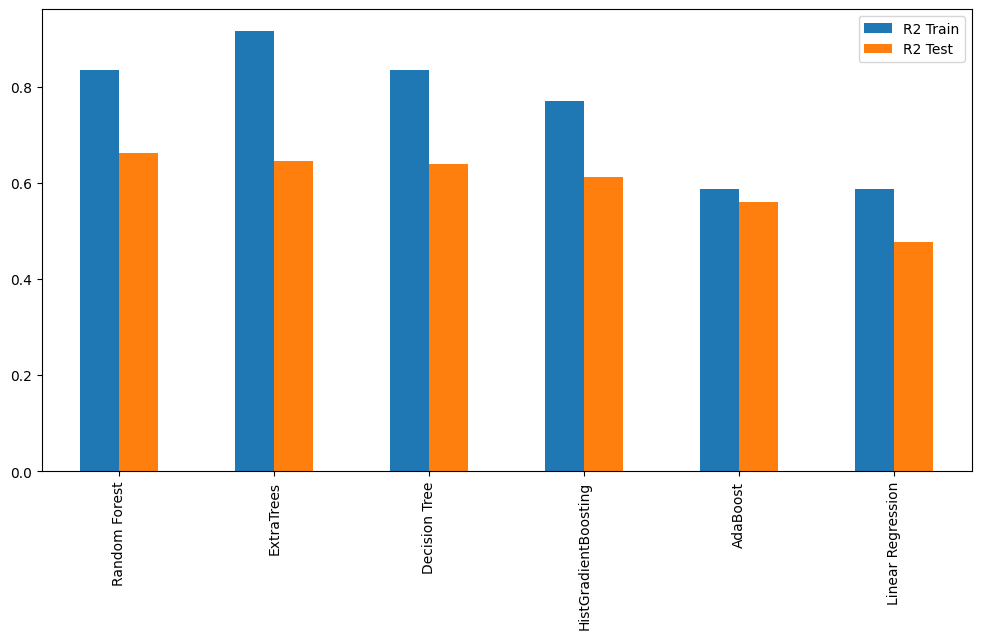

In [ ]:
errors_df[["R2 Train", "R2 Test"]].plot.bar(figsize=(12,6))

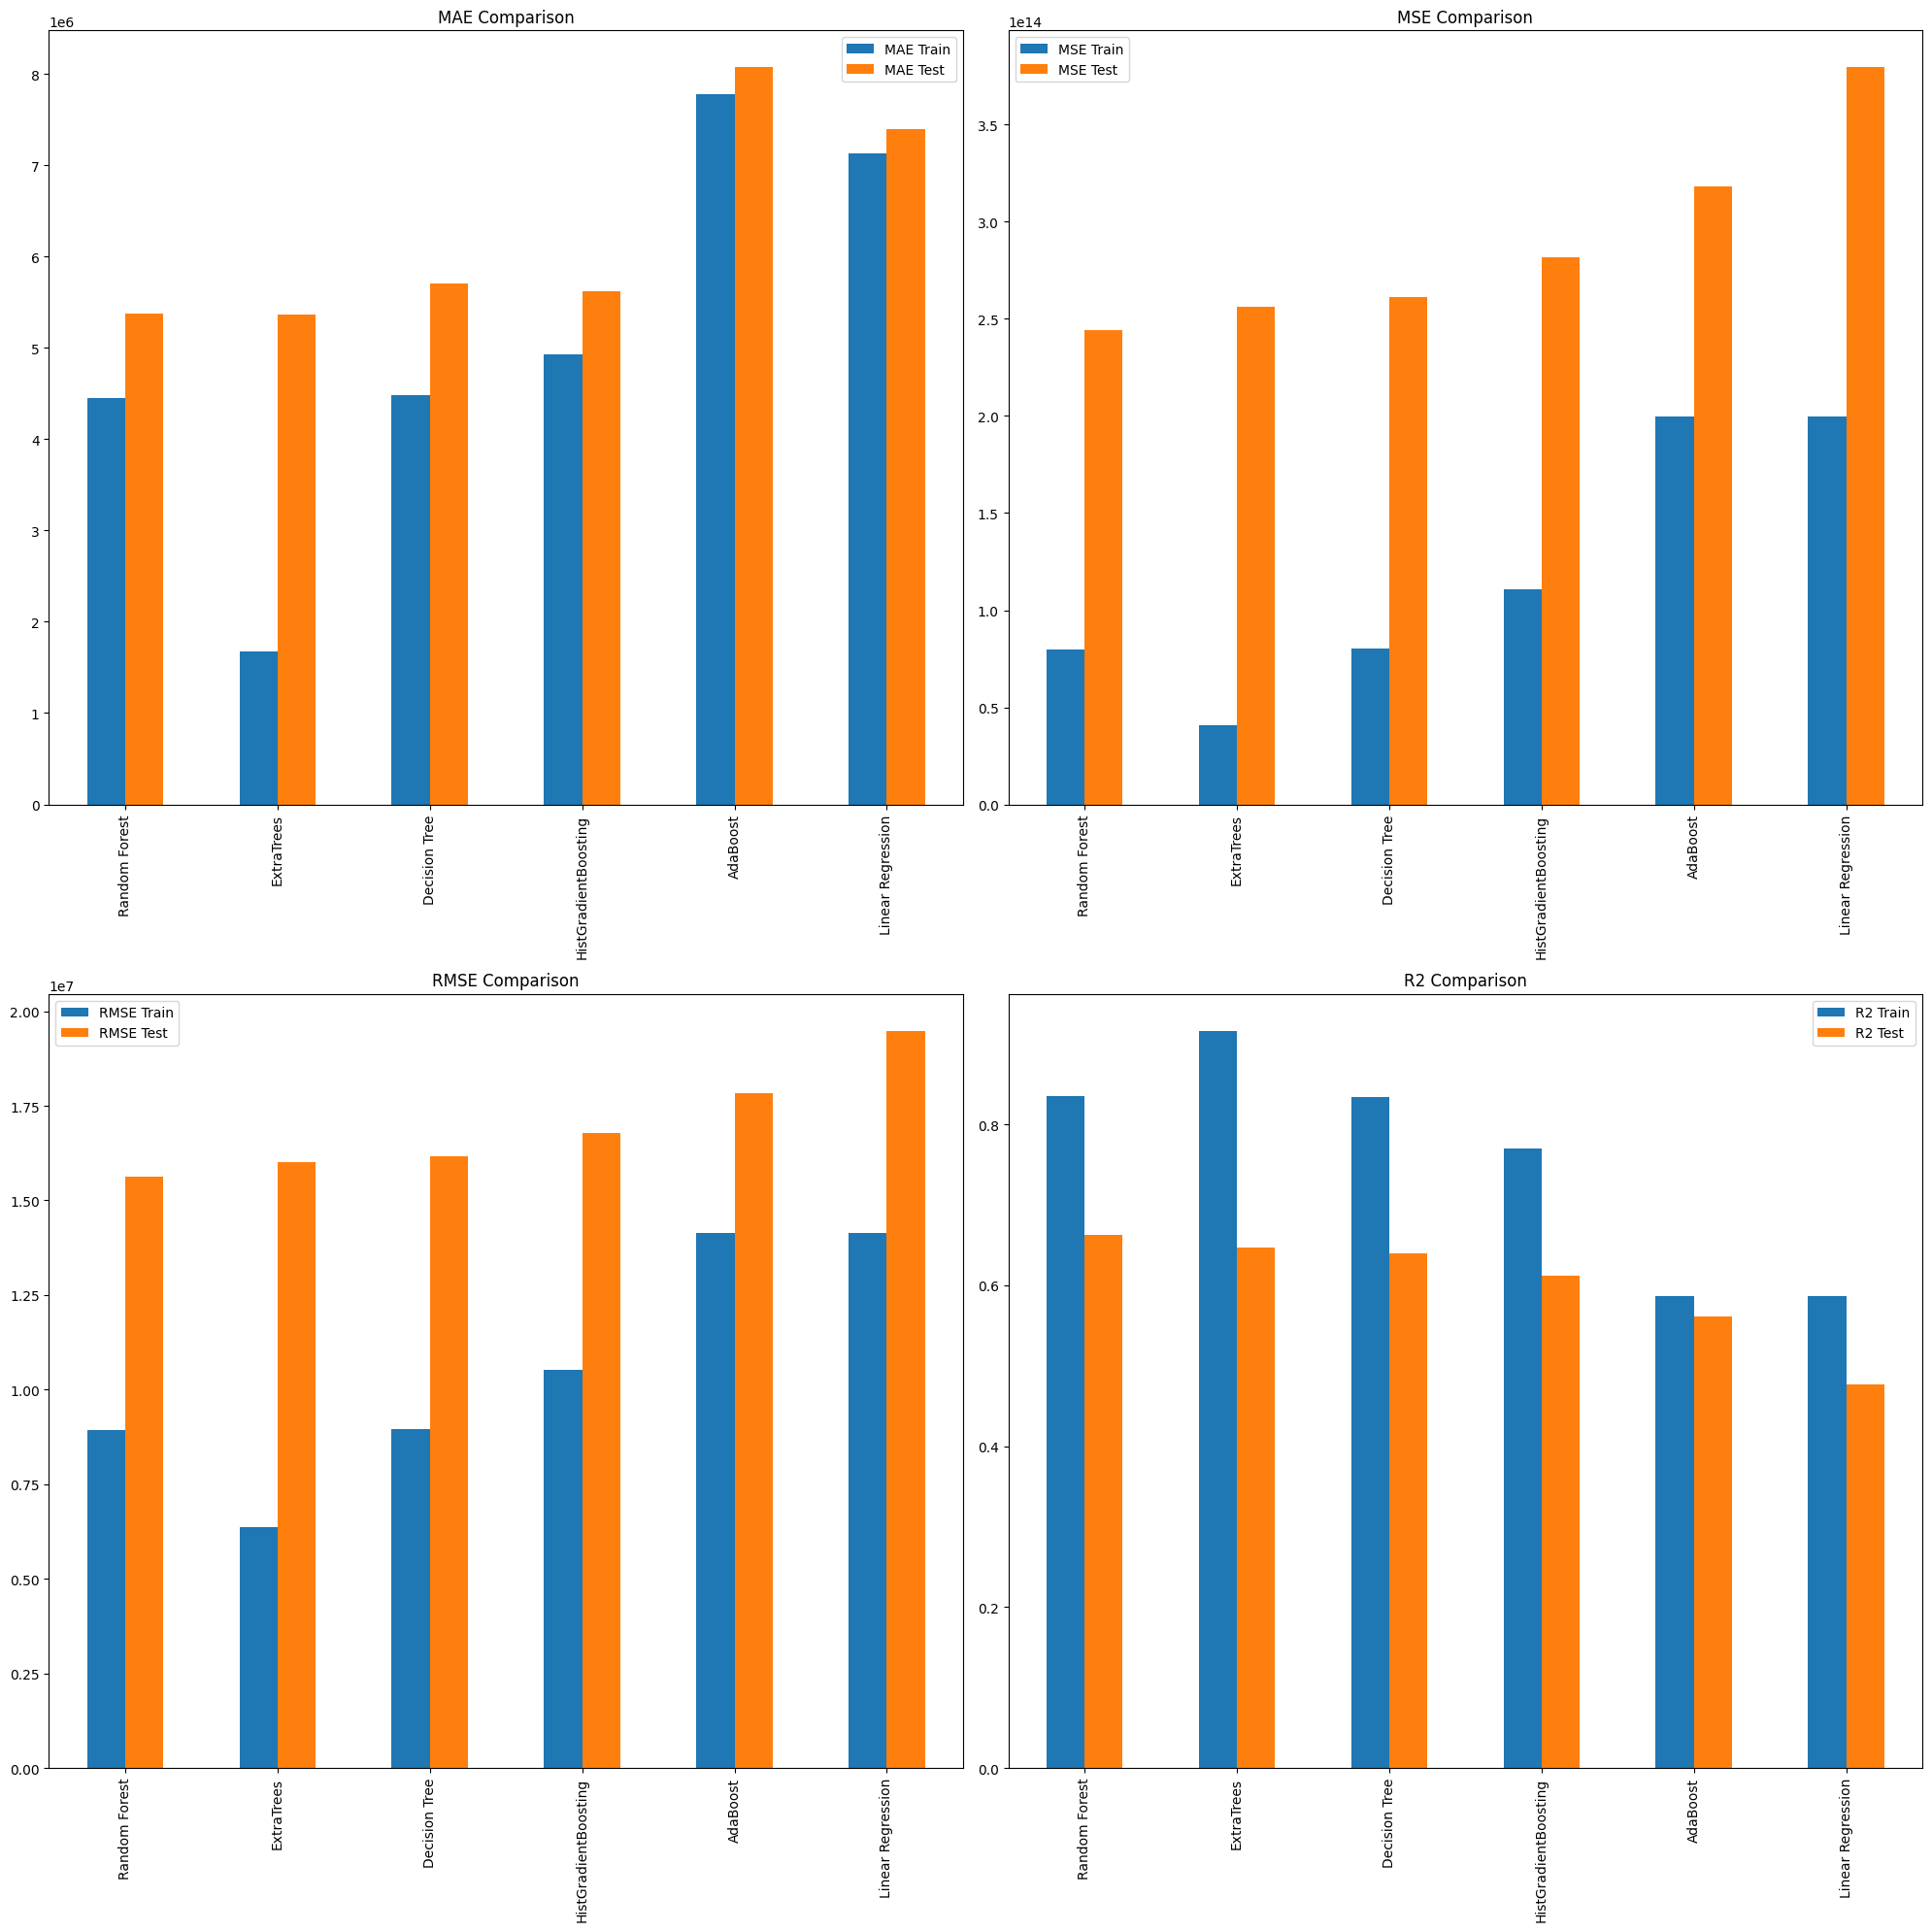

In [ ]:
cols = [
    ['MAE Train', 'MAE Test'],
    ['MSE Train', 'MSE Test'],
    ['RMSE Train', 'RMSE Test'],
    ['R2 Train', 'R2 Test']
]

plt.figure(figsize=(20,20))

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i+1)
    errors_df[col].plot.bar(ax=ax)
    ax.set_title(col[0].split(" ")[0] + ' Comparison')

plt.tight_layout()
plt.show()